<h1 style="text-align:center;">Ito Calculus<br></h1>
<div style="text-align:center;">Ariel Kalingking</div>
<div style="text-align:center;">akalingking@gmail.com</div>
<div style="text-align:center;">Appendix: Python Code</div>

In [1]:
import math
import numpy as np
import statsmodels.api as sm
import logging
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

plt_inline_enable = False # Turn this off when running makefile
imagepath = "../paper/figures/"
figsize = (4,3)
fontbig = 8
fontmed = 7
fontsmall = 6
matplotlib.use('TkAgg')
logging.getLogger().setLevel(logging.ERROR)
if plt_inline_enable:
    %matplotlib inline

In [2]:
np.random.seed(18)
T = 1                 # Time horizon
N = 252               # Number of step
dt = T/N              # Time interval
int_sum = np.zeros(N) # Discrete sum integral
# Initialize data vectores
Wt = np.zeros(N)               # Brownian steps
time = np.full(N, dt).cumsum() # Time steps

# Set initial values
Wt[0] = np.sqrt(dt) * np.random.randn()
# Run the simulation
for n in range(N-1):
    dWt = np.sqrt(dt) * np.random.randn()
    Wt[n+1] = Wt[n] + dWt
    int_sum[n+1] = int_sum[n] + Wt[n]*(Wt[n+1] - Wt[n])
    
# Analytical integral value
Ito_int = 0.5 * (Wt[-1]**2 - T)
# Calculate error
error = abs(int_sum[-1] - Ito_int)
error_pct = abs(error/Ito_int)*100

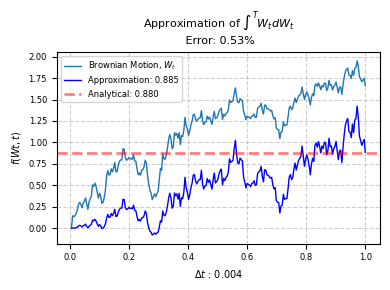

In [3]:
fig =  plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
ax.plot(time, Wt, linewidth=1, label=f"Brownian Motion, $W_t$")
ax.plot(time, int_sum, linewidth=1, color="blue", 
        label=f"Approximation: {int_sum[-1]:.3f}")
ax.axhline(Ito_int, color="red", linestyle="--", linewidth=2, alpha=0.5,
           label=f"Analytical: {Ito_int:.3f}")
ax.set_title(f"Approximation of $\int^T W_t dW_t$\n Error: {error_pct:.2f}%", 
             fontsize=fontbig, fontweight="normal")
ax.set_xlabel(f"$\Delta t$ : {dt:.3f}", fontsize=fontmed)
ax.set_ylabel("$f(Wt,t)$", fontsize=fontmed)
ax.grid(True, linestyle="--", alpha=0.6)
ax.tick_params(axis='both', which='major', labelsize=fontsmall) 
ax.legend(loc="best", fontsize=fontsmall)
plt.tight_layout()
plt.savefig(imagepath+"ito_integral_1.pdf", bbox_inches="tight")
if plt_inline_enable:
    plt.show()